## Task 1 Load and Prepare

In [2]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [4]:
X= df.drop(columns="target")
y= df["target"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape


(216, 13)

In [6]:
X_test.shape

(54, 13)

## Task 2 Train a Lonely Tree

In [41]:
dt= DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_train_pred= dt.predict(X_train)
dt_test_pred= dt.predict(X_test)

dt_train_acc= accuracy_score(y_train, dt_train_pred)
dt_test_acc= accuracy_score(y_test, dt_test_pred)

print("Decision Tree Training Accuracy", round(dt_train_acc, 2))
print("Decision Tree Test Accuracy", round(dt_test_acc,2))


Decision Tree Training Accuracy 1.0
Decision Tree Test Accuracy 0.69


The model is overfit and memorized the training data because our max depth is infinity and beyond.

## Task 3 Visualize the Decision Tree

In [8]:
print(export_text(dt, feature_names=list(X.columns)))

|--- cp <= 2.50
|   |--- oldpeak <= 2.45
|   |   |--- thal <= 1.50
|   |   |   |--- chol <= 272.00
|   |   |   |   |--- trestbps <= 109.00
|   |   |   |   |   |--- chol <= 232.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- chol >  232.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- trestbps >  109.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- chol >  272.00
|   |   |   |   |--- oldpeak <= 1.35
|   |   |   |   |   |--- thalach <= 138.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- thalach >  138.00
|   |   |   |   |   |   |--- chol <= 330.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- chol >  330.00
|   |   |   |   |   |   |   |--- chol <= 337.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- chol >  337.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  1.35
|   |   |   |   |   |--- class: 1
|   |   |--- thal >  1.50
|   |   |   |--- thalac

In [9]:
dt.get_depth()

10

In [10]:
dt.get_n_leaves()

np.int64(36)

The first question in the tree refers to the CP - which we are interpreting as Chest Pain score.  it splits into greater than or less than 2.5  

## Task 4: Give Your Tree Some Friends

In [11]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
rf_train_pred= rf.predict(X_train)
rf_test_pred= rf.predict(X_test)

rf_train_acc= accuracy_score(y_train, rf_train_pred)
rf_test_acc= accuracy_score(y_test, rf_test_pred)

print("RF Training Accuracy", round(rf_train_acc, 2))
print("RF Test Accuracy", round(rf_test_acc,2))


RF Training Accuracy 1.0
RF Test Accuracy 0.8


The test accuracy improved on this model.The gap is smaller between training and test, which meanas it reduced the overfit

## Task 5 : Train an XGBoost Model

In [17]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_train_pred= xgb.predict(X_train)
xgb_test_pred= xgb.predict(X_test)

xgb_train_acc= accuracy_score(y_train, xgb_train_pred)
xgb_test_acc= accuracy_score(y_test, xgb_test_pred)

print("XGB Training Accuracy", round(xgb_train_acc, 2))
print("XGB Test Accuracy", round(xgb_test_acc,2))

XGB Training Accuracy 1.0
XGB Test Accuracy 0.85


XGBoost's accuracy is better by 0.05. Both models have perfect accuracy on the training set, but because XGBoost has higher accuracy in the test set, the gap is smaller, meaning it is less prone to overfit.

## Task 6: Compare All Three Models

| Model           | Train Accuracy | Test Accuracy |
|-----------------|----------------|---------------|
| Decision Tree   |      1.0       |      0.69     |
| Random Forest   |      1.0       |       0.8     |
| XGBoost         |      1.0       |      0.85     |


We recommend the XGBoost model because it has the highest accuracy and smallest gap between training and test accuracy. Suspiciously, every training accuracy is 1.0... **We blame Denise.**

## Task 7

age         0.095171
sex         0.025117
cp          0.133470
trestbps    0.079547
chol        0.083485
fbs         0.009276
restecg     0.018442
thalach     0.105259
exang       0.052720
oldpeak     0.138002
slope       0.059689
ca          0.085092
thal        0.114730
dtype: float64


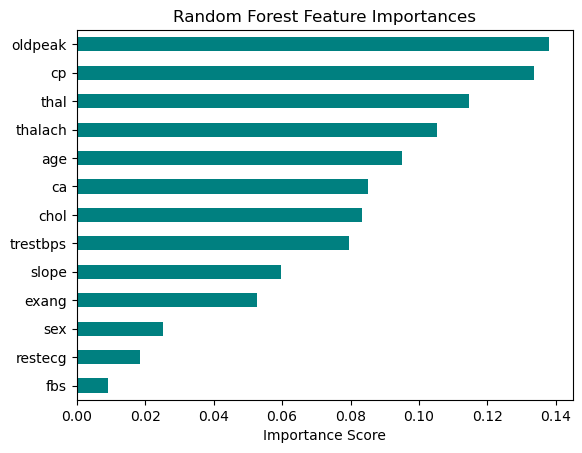

In [31]:
rf_importances = pd.Series(rf.feature_importances_, index=list(X.columns))
print(rf_importances)

rf_importances = rf_importances.sort_values(ascending=True)
rf_importances.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.show()

The feature `oldpeak` had the most influence on the model's predictions, followed closely by `cp`. Yes these efatures make sense for predicting heart disease. Old Peak measures something not working right with an ECG, and CP measures someone's reported chest pain.

# Advanced Tasks

## Advanced Task 1: Use Cross-Validation

In [39]:
models = {
    'Lonely Tree': dt,
    'Tree w/ Friends': rf,
    'Boost Gang': xgb
}

print(f"{'Model':<20} {'CV Mean':>8}  {'CV Std':>7}")
print("-" * 38)
for name,model in models.items():
    scores = cross_val_score(model, X, y, cv = 5, scoring='accuracy')
    print(f"{name:<20} {scores.mean():>8.2f}  {scores.std():>7.2f}")

Model                 CV Mean   CV Std
--------------------------------------
Lonely Tree              0.72     0.09
Tree w/ Friends          0.81     0.06
Boost Gang               0.79     0.06


Yes, the rankings did change. Tree w/ friends (RF) has become the best performer. RF and XGB both have a standard deviation of 0.06, meaning they have the least variance in the scores (all 5 tests provided relatively similar accuracy to each other)

## Advanced Task 2: Control Overfit

In [ ]:
depths = [2, 5, None]
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(random_state=42, max_depth=depth)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(y_test))

    train_accs.append(train_acc)
    test_accs.append(test_acc)